<center>
<img src="https://habrastorage.org/files/fd4/502/43d/fd450243dd604b81b9713213a247aa20.jpg">
    
## [mlcourse.ai](https://mlcourse.ai) - Open Machine Learning Course

Authors: [Maria Sumarokova](https://www.linkedin.com/in/mariya-sumarokova-230b4054/), and [Yury Kashnitsky](https://www.linkedin.com/in/festline/). Translated and edited by Gleb Filatov, Aleksey Kiselev, [Anastasia Manokhina](https://www.linkedin.com/in/anastasiamanokhina/), [Egor Polusmak](https://www.linkedin.com/in/egor-polusmak/), and [Yuanyuan Pao](https://www.linkedin.com/in/yuanyuanpao/). All content is distributed under the [Creative Commons CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/) license.

# <center> Assignment #3 (demo)
## <center>  Decision trees with a toy task and the UCI Adult dataset 

Same assignment as a [Kaggle Kernel](https://www.kaggle.com/kashnitsky/a3-demo-decision-trees) + [solution](https://www.kaggle.com/kashnitsky/a3-demo-decision-trees-solution). Fill in the answers in the [web-form](https://docs.google.com/forms/d/1wfWYYoqXTkZNOPy1wpewACXaj2MZjBdLOL58htGWYBA/edit).

Let's start by loading all necessary libraries:

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (10, 8)
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import collections
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from ipywidgets import Image
from io import StringIO
import pydotplus #pip install pydotplus

### Part 1. Toy dataset "Will They? Won't They?"

Your goal is to figure out how decision trees work by walking through a toy problem. While a single decision tree does not yield outstanding results, other performant algorithms like gradient boosting and random forests are based on the same idea. That is why knowing how decision trees work might be useful.

We'll go through a toy example of binary classification - Person A is deciding whether they will go on a second date with Person B. It will depend on their looks, eloquence, alcohol consumption (only for example), and how much money was spent on the first date.

#### Creating the dataset

In [2]:
# Create dataframe with dummy variables
def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis = 1)
    out.drop(feature_list, axis = 1, inplace = True)
    return out

# Some feature values are present in train and absent in test and vice-versa.
def intersect_features(train, test):
    common_feat = list( set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

In [3]:
features = ['Looks', 'Alcoholic_beverage','Eloquence','Money_spent']

#### Training data

In [4]:
df_train = {}
df_train['Looks'] = ['handsome', 'handsome', 'handsome', 'repulsive',
                         'repulsive', 'repulsive', 'handsome'] 
df_train['Alcoholic_beverage'] = ['yes', 'yes', 'no', 'no', 'yes', 'yes', 'yes']
df_train['Eloquence'] = ['high', 'low', 'average', 'average', 'low',
                                   'high', 'average']
df_train['Money_spent'] = ['lots', 'little', 'lots', 'little', 'lots',
                                  'lots', 'lots']
df_train['Will_go'] = LabelEncoder().fit_transform(['+', '-', '+', '-', '-', '+', '+'])

df_train = create_df(df_train, features)
df_train

,Will_go,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Eloquence_low,Money_spent_little,Money_spent_lots
0,0,True,False,False,True,False,True,False,False,True
1,1,True,False,False,True,False,False,True,True,False
2,0,True,False,True,False,True,False,False,False,True
3,1,False,True,True,False,True,False,False,True,False
4,1,False,True,False,True,False,False,True,False,True
5,0,False,True,False,True,False,True,False,False,True
6,0,True,False,False,True,True,False,False,False,True


#### Test data

In [5]:
df_test = {}
df_test['Looks'] = ['handsome', 'handsome', 'repulsive'] 
df_test['Alcoholic_beverage'] = ['no', 'yes', 'yes']
df_test['Eloquence'] = ['average', 'high', 'average']
df_test['Money_spent'] = ['lots', 'little', 'lots']
df_test = create_df(df_test, features)
df_test

,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Money_spent_little,Money_spent_lots
0,True,False,True,False,True,False,False,True
1,True,False,False,True,False,True,True,False
2,False,True,False,True,True,False,False,True


In [6]:
# Some feature values are present in train and absent in test and vice-versa.
y = df_train['Will_go']
df_train, df_test = intersect_features(train=df_train, test=df_test)
df_train

,Alcoholic_beverage_yes,Looks_handsome,Eloquence_high,Alcoholic_beverage_no,Looks_repulsive,Money_spent_lots,Eloquence_average,Money_spent_little
0,True,True,True,False,False,True,False,False
1,True,True,False,False,False,False,False,True
2,False,True,False,True,False,True,True,False
3,False,False,False,True,True,False,True,True
4,True,False,False,False,True,True,False,False
5,True,False,True,False,True,True,False,False
6,True,True,False,False,False,True,True,False


In [7]:
df_test

,Alcoholic_beverage_yes,Looks_handsome,Eloquence_high,Alcoholic_beverage_no,Looks_repulsive,Money_spent_lots,Eloquence_average,Money_spent_little
0,False,True,False,True,False,True,True,False
1,True,True,True,False,False,False,False,True
2,True,False,False,False,True,True,True,False


#### Draw a decision tree (by hand or in any graphics editor) for this dataset. Optionally you can also implement tree construction and draw it here.

1\. What is the entropy $S_0$ of the initial system? By system states, we mean values of the binary feature "Will_go" - 0 or 1 - two states in total.

In [8]:
# you code here
S0 = -(4/7) * np.log2(4/7) - (3/7) * np.log2(3/7)
print(S0)

0.9852281360342515


2\. Let's split the data by the feature "Looks_handsome". What is the entropy $S_1$ of the left group - the one with "Looks_handsome". What is the entropy $S_2$ in the opposite group? What is the information gain (IG) if we consider such a split?

In [9]:
# you code here
S1 = -(3/4) * np.log2(3/4) - (1/4) * np.log2(1/4)
S2 = -(1/3) * np.log2(1/3) - (2/3) * np.log2(2/3)

IG = S0 - (4/7) * S1 - (3/7) * S2

print(S1, S2, IG)

0.8112781244591328 0.9182958340544896 0.12808527889139443


#### Train a decision tree using sklearn on the training data. You may choose any depth for the tree.

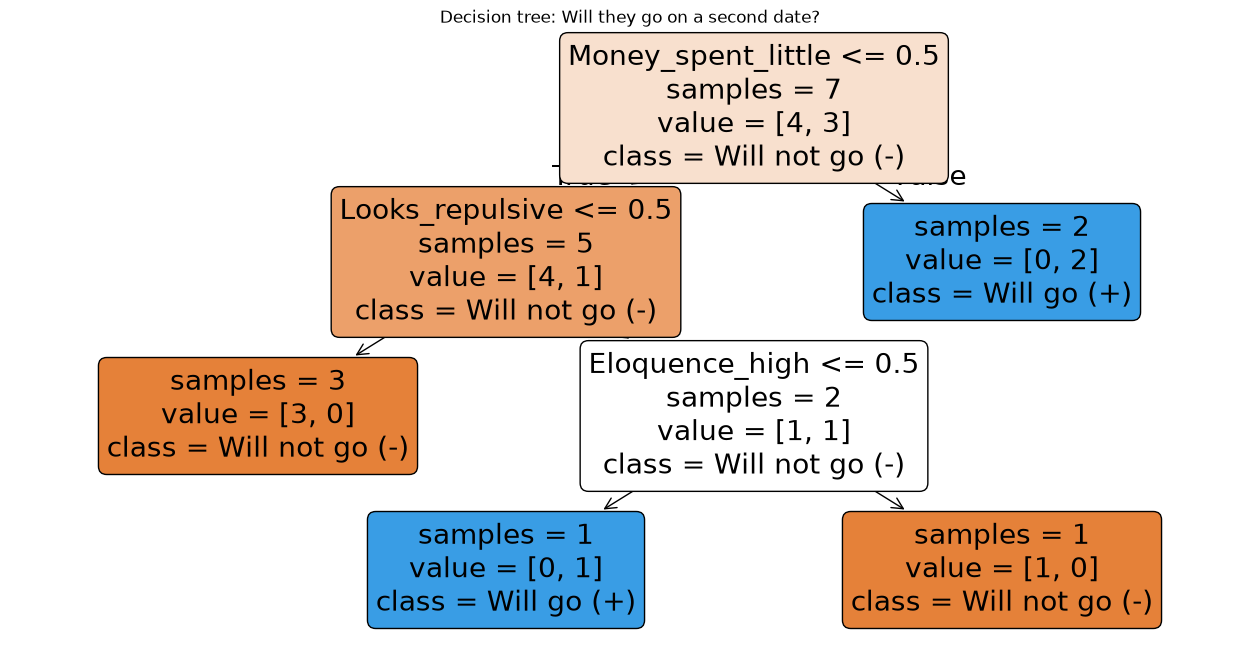

In [10]:
# you code here
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(df_train, y)

plt.figure(figsize=(16, 8))
plot_tree(
    tree,
    feature_names=df_train.columns,
    class_names=['Will not go (-)', 'Will go (+)'],
    filled=True,
    rounded=True,
    impurity=False,
)
plt.title('Decision tree: Will they go on a second date?')
plt.show()

#### Additional: display the resulting tree using graphviz. You can use pydot or [web-service](https://www.coolutils.com/ru/online/DOT-to-PNG) dot2png.

In [11]:
# you code here
dot_data = StringIO()

export_graphviz(
    tree,
    out_file=dot_data,
    feature_names=df_train.columns,
    class_names=['Will not go (-)', 'Will go (+)'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(data=graph.create_png())

Image(value=b'')

### Part 2. Functions for calculating entropy and information gain.

Consider the following warm-up example: we have 9 blue balls and 11 yellow balls. Let ball have label **1** if it is blue, **0** otherwise.

In [12]:
balls = [1 for i in range(9)] + [0 for i in range(11)]

<img src = 'https://habrastorage.org/webt/mu/vl/mt/muvlmtd2njeqf18trbldenpqvnm.png'>

Next split the balls into two groups:

<img src='https://habrastorage.org/webt/bd/aq/5w/bdaq5wi3c4feezaexponvin8wmo.png'>

In [13]:
# two groups
balls_left  = [1 for i in range(8)] + [0 for i in range(5)] # 8 blue and 5 yellow
balls_right = [1 for i in range(1)] + [0 for i in range(6)] # 1 blue and 6 yellow

#### Implement a function to calculate the Shannon Entropy

In [14]:
def entropy(a_list):
    # you code here
    counts = np.unique(a_list, return_counts=True)[1]
    probabilities = counts / counts.sum()
    
    return -np.sum(probabilities * np.log2(probabilities))
    pass

Tests

In [15]:
print(entropy(balls)) # 9 blue и 11 yellow
print(entropy(balls_left)) # 8 blue и 5 yellow
print(entropy(balls_right)) # 1 blue и 6 yellow
print(entropy([1,2,3,4,5,6])) # entropy of a fair 6-sided die

0.9927744539878083
0.9612366047228759
0.5916727785823275
2.584962500721156


3\. What is the entropy of the state given by the list **balls_left**?

0.96

4\. What is the entropy of a fair dice? (where we look at a dice as a system with 6 equally probable states)?

In [16]:
fair_dice = [1, 2, 3, 4, 5, 6]

print(entropy(fair_dice))

2.584962500721156


In [17]:
# information gain calculation
def information_gain(root, left, right):
    """root - initial data, left and right - two partitions of initial data"""
    
    # you code here
    root_entropy = entropy(root)
    
    left_weight = len(left) / len(root)
    right_weight = len(right) / len(root)
    
    split_entropy = (
        left_weight * entropy(left) +
        right_weight * entropy(right)
    )
    
    return root_entropy - split_entropy

print(information_gain(balls, balls_left, balls_right))

0.16088518841412436


5\. What is the information gain from splitting the initial dataset into **balls_left** and **balls_right** ?

0.16

In [18]:
def best_feature_to_split(X, y):
    '''Outputs information gain when splitting on best feature'''
    
    # you code here
    gains = {}

    for feature in X.columns:
        left = y[X[feature] == 1]
        right = y[X[feature] == 0]

        if len(left) > 0 and len(right) > 0:
            gains[feature] = information_gain(y, left, right)

    best_feature = max(gains, key=gains.get)
    return best_feature, gains[best_feature]

In [19]:
print(information_gain(balls, balls_left, balls_right))

0.16088518841412436


#### Optional:
- Implement a decision tree building algorithm by calling **best_feature_to_split** recursively
- Plot the resulting tree

In [20]:
def find_best_feature(X, y):
    """Повертає назву ознаки з найбільшим information gain"""
    
    gains = {}

    for feature in X.columns:
        y_yes = y[X[feature] == 1]
        y_no = y[X[feature] == 0]

        if len(y_yes) > 0 and len(y_no) > 0:
            gains[feature] = information_gain(y, y_yes, y_no)

    return max(gains, key=gains.get)


def build_tree(X, y):
    """Рекурсивно будує дерево та повертає його як словник"""

    # Усі приклади належать одному класу → листок
    if y.nunique() == 1:
        return y.iloc[0]

    # Ознак не залишилось → найчастіший клас
    if X.shape[1] == 0:
        return y.mode()[0]

    best_feature = find_best_feature(X, y)

    X_yes = X[X[best_feature] == 1].drop(columns=[best_feature])
    y_yes = y[X[best_feature] == 1]

    X_no = X[X[best_feature] == 0].drop(columns=[best_feature])
    y_no = y[X[best_feature] == 0]

    return {
        'feature': best_feature,
        'yes': build_tree(X_yes, y_yes),
        'no': build_tree(X_no, y_no)
    }


def print_tree(tree, indent=''):
    """Друкує дерево"""

    if not isinstance(tree, dict):
        print(f'{indent}→ Will_go = {tree}')
        return

    feature = tree['feature']
    print(f'{indent}{feature} = 1?')

    print(f'{indent}├─ Так:')
    print_tree(tree['yes'], indent + '│  ')

    print(f'{indent}└─ Ні:')
    print_tree(tree['no'], indent + '   ')


my_tree = build_tree(df_train, y)
print_tree(my_tree)

Money_spent_lots = 1?
├─ Так:
│  Looks_handsome = 1?
│  ├─ Так:
│  │  → Will_go = 0
│  └─ Ні:
│     Eloquence_high = 1?
│     ├─ Так:
│     │  → Will_go = 0
│     └─ Ні:
│        → Will_go = 1
└─ Ні:
   → Will_go = 1


### Part 3. The "Adult" dataset

#### Dataset description:

[Dataset](http://archive.ics.uci.edu/ml/machine-learning-databases/adult) UCI Adult (no need to download it, we have a copy in the course repository): classify people using demographical data - whether they earn more than \$50,000 per year or not.

Feature descriptions:

- **Age** – continuous feature
- **Workclass** –  continuous feature
- **fnlwgt** – final weight of object, continuous feature
- **Education** –  categorical feature
- **Education_Num** – number of years of education, continuous feature
- **Martial_Status** –  categorical feature
- **Occupation** –  categorical feature
- **Relationship** – categorical feature
- **Race** – categorical feature
- **Sex** – categorical feature
- **Capital_Gain** – continuous feature
- **Capital_Loss** – continuous feature
- **Hours_per_week** – continuous feature
- **Country** – categorical feature

**Target** – earnings level, categorical (binary) feature.

#### Reading train and test data

In [21]:
data_train = pd.read_csv('data/adult_train.csv')

In [22]:
data_train.tail()

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [23]:
data_test = pd.read_csv('data/adult_test.csv')

In [24]:
data_test.tail()

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K.
16278,64,NaN,321403.0,HS-grad,9.0,Widowed,NaN,Other-relative,Black,Male,0.0,0.0,40.0,United-States,<=50K.
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.
16281,35,Self-emp-inc,182148.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,60.0,United-States,>50K.


In [25]:
# necessary to remove rows with incorrect labels in test dataset
data_test = data_test[
    (data_test['Target'] == ' >50K.') |
    (data_test['Target'] == ' <=50K.')
]

# encode target variable as integer
data_train['Target'] = data_train['Target'].map({
    ' <=50K': 0,
    ' >50K': 1
})

data_test['Target'] = data_test['Target'].map({
    ' <=50K.': 0,
    ' >50K.': 1
})

#### Primary data analysis

In [26]:
data_test.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,16281,73,35,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Workclass,15318,8,Private,11210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,16281.0,NaN,NaN,NaN,189435.677784,105714.907671,13492.0,116736.0,177831.0,238384.0,1490400.0
Education,16281,16,HS-grad,5283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Num,16281.0,NaN,NaN,NaN,10.072907,2.567545,1.0,9.0,10.0,12.0,16.0
Martial_Status,16281,7,Married-civ-spouse,7403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,15315,14,Prof-specialty,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Relationship,16281,6,Husband,6523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,16281,5,White,13946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,16281,2,Male,10860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
data_train['Target'].value_counts()

Target
0    24720
1     7841
Name: count, dtype: int64

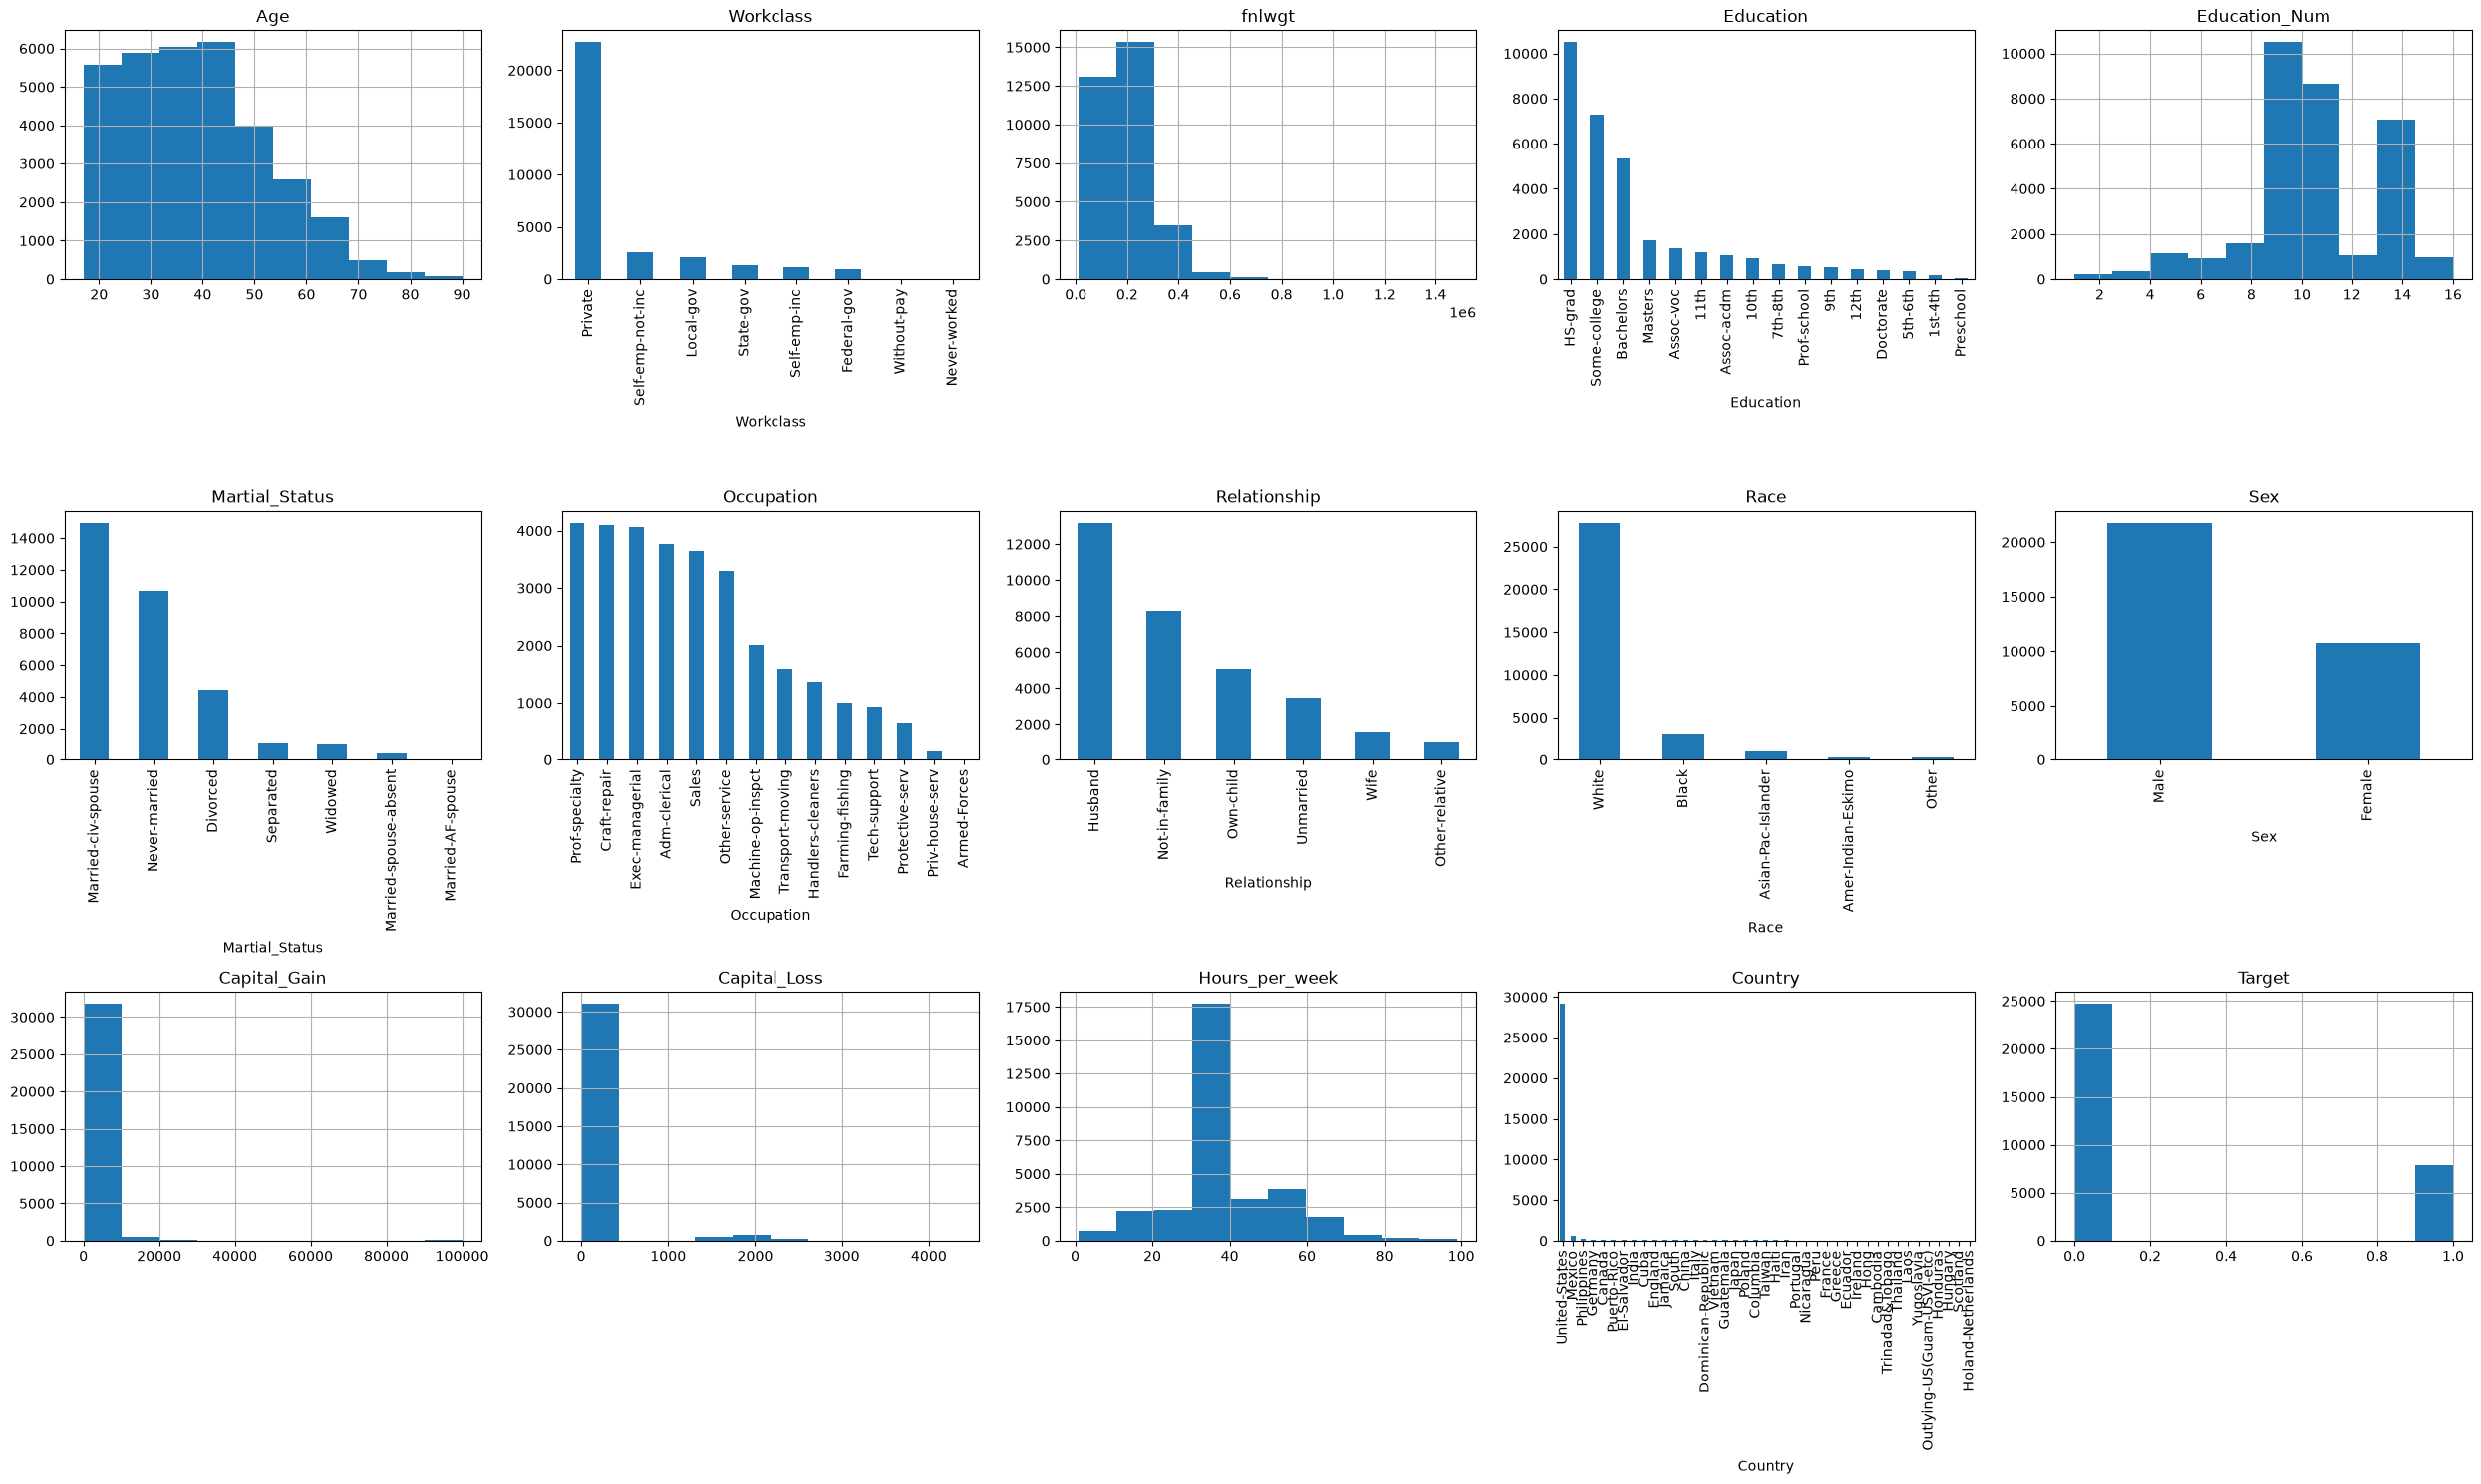

In [28]:
fig = plt.figure(figsize=(25, 15))
cols = 5
rows = int(np.ceil(data_train.shape[1] / cols))

for i, column in enumerate(data_train.columns):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.set_title(column)

    if pd.api.types.is_numeric_dtype(data_train[column]):
        data_train[column].hist(ax=ax)
    else:
        data_train[column].value_counts().plot(kind='bar', ax=ax)
        ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#### Checking data types

In [29]:
data_train.dtypes

Age               int64
Workclass           str
fnlwgt            int64
Education           str
Education_Num     int64
Martial_Status      str
Occupation          str
Relationship        str
Race                str
Sex                 str
Capital_Gain      int64
Capital_Loss      int64
Hours_per_week    int64
Country             str
Target            int64
dtype: object

In [30]:
data_test.dtypes

Age                   str
Workclass             str
fnlwgt            float64
Education             str
Education_Num     float64
Martial_Status        str
Occupation            str
Relationship          str
Race                  str
Sex                   str
Capital_Gain      float64
Capital_Loss      float64
Hours_per_week    float64
Country               str
Target              int64
dtype: object

As we see, in the test data, age is treated as type **object**. We need to fix this.

In [31]:
data_test['Age'] = data_test['Age'].astype(int)

Also we'll cast all **float** features to **int** type to keep types consistent between our train and test data.

In [32]:
data_test['fnlwgt'] = data_test['fnlwgt'].astype(int)
data_test['Education_Num'] = data_test['Education_Num'].astype(int)
data_test['Capital_Gain'] = data_test['Capital_Gain'].astype(int)
data_test['Capital_Loss'] = data_test['Capital_Loss'].astype(int)
data_test['Hours_per_week'] = data_test['Hours_per_week'].astype(int)

#### Fill in missing data for continuous features with their median values, for categorical features with their mode.

In [33]:
# choose categorical and continuous features from data

categorical_columns = [c for c in data_train.columns 
                       if data_train[c].dtype.name == 'object']
numerical_columns = [c for c in data_train.columns 
                     if data_train[c].dtype.name != 'object']

print('categorical_columns:', categorical_columns)
print('numerical_columns:', numerical_columns)

categorical_columns: []
numerical_columns: ['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target']


In [34]:
# we see some missing values
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_Num   32561 non-null  int64
 5   Martial_Status  32561 non-null  str  
 6   Occupation      30718 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_Gain    32561 non-null  int64
 11  Capital_Loss    32561 non-null  int64
 12  Hours_per_week  32561 non-null  int64
 13  Country         31978 non-null  str  
 14  Target          32561 non-null  int64
dtypes: int64(7), str(8)
memory usage: 3.7 MB


In [35]:
# fill missing data

categorical_columns = data_train.select_dtypes(exclude='number').columns
numerical_columns = data_train.select_dtypes(include='number').columns

for c in categorical_columns:
    fill_value = data_train[c].mode()[0]
    data_train[c] = data_train[c].fillna(fill_value)
    data_test[c] = data_test[c].fillna(fill_value)

for c in numerical_columns:
    fill_value = data_train[c].median()
    data_train[c] = data_train[c].fillna(fill_value)
    data_test[c] = data_test[c].fillna(fill_value)

In [36]:
# no more missing values
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_Num   32561 non-null  int64
 5   Martial_Status  32561 non-null  str  
 6   Occupation      32561 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_Gain    32561 non-null  int64
 11  Capital_Loss    32561 non-null  int64
 12  Hours_per_week  32561 non-null  int64
 13  Country         32561 non-null  str  
 14  Target          32561 non-null  int64
dtypes: int64(7), str(8)
memory usage: 3.7 MB


We'll dummy code some categorical features: **Workclass**, **Education**, **Martial_Status**, **Occupation**, **Relationship**, **Race**, **Sex**, **Country**. It can be done via pandas method **get_dummies**

In [37]:
data_train = pd.concat([data_train[numerical_columns],
    pd.get_dummies(data_train[categorical_columns])], axis=1)

data_test = pd.concat([data_test[numerical_columns],
    pd.get_dummies(data_test[categorical_columns])], axis=1)

In [38]:
set(data_train.columns) - set(data_test.columns)

{'Country_ Holand-Netherlands'}

In [39]:
data_train.shape, data_test.shape

((32561, 106), (16281, 105))

#### There is no Holland in the test data. Create new zero-valued feature.

In [40]:
data_test['Country_ Holand-Netherlands'] = 0

In [41]:
set(data_train.columns) - set(data_test.columns)

set()

In [42]:
data_train.head(2)

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week,Target,Workclass_ Federal-gov,Workclass_ Local-gov,Workclass_ Never-worked,...,Country_ Portugal,Country_ Puerto-Rico,Country_ Scotland,Country_ South,Country_ Taiwan,Country_ Thailand,Country_ Trinadad&Tobago,Country_ United-States,Country_ Vietnam,Country_ Yugoslavia
0,39,77516,13,2174,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [43]:
data_test.head(2)

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week,Target,Workclass_ Federal-gov,Workclass_ Local-gov,Workclass_ Never-worked,...,Country_ Puerto-Rico,Country_ Scotland,Country_ South,Country_ Taiwan,Country_ Thailand,Country_ Trinadad&Tobago,Country_ United-States,Country_ Vietnam,Country_ Yugoslavia,Country_ Holand-Netherlands
1,25,226802,7,0,0,40,0,False,False,False,...,False,False,False,False,False,False,True,False,False,0
2,38,89814,9,0,0,50,0,False,False,False,...,False,False,False,False,False,False,True,False,False,0


In [44]:
X_train = data_train.drop(['Target'], axis=1)
y_train = data_train['Target']

X_test = data_test.drop(['Target'], axis=1)
y_test = data_test['Target']

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### 3.1 Decision tree without parameter tuning

Train a decision tree **(DecisionTreeClassifier)** with a maximum depth of 3, and evaluate the accuracy metric on the test data. Use parameter **random_state = 17** for results reproducibility.

In [45]:
# you code here
tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=17
)

tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",17
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Make a prediction with the trained model on the test data.

In [46]:
# you code here
tree_predictions = tree.predict(X_test)

In [47]:
# you code here
print('Accuracy:', accuracy_score(y_test, tree_predictions))

Accuracy: 0.8447884036607088


6\. What is the test set accuracy of a decision tree with maximum tree depth of 3 and **random_state = 17**?

0.84

### 3.2 Decision tree with parameter tuning

Train a decision tree **(DecisionTreeClassifier, random_state = 17).** Find the optimal maximum depth using 5-fold cross-validation **(GridSearchCV)**.

In [48]:
tree_params = {'max_depth': range(2,11)}

# you code here                     
locally_best_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=17),
    param_grid=tree_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

locally_best_tree.fit(X_train, y_train)

print('Best parameters:', locally_best_tree.best_params_)
print('Best CV accuracy:', locally_best_tree.best_score_)
locally_best_tree.fit; 

Best parameters: {'max_depth': 9}
Best CV accuracy: 0.8565770273854106


Train a decision tree with maximum depth of 9 (it is the best **max_depth** in my case), and compute the test set accuracy. Use parameter **random_state = 17** for reproducibility.

In [49]:
tuned_tree = DecisionTreeClassifier(
    max_depth=9,
    random_state=17
)

tuned_tree.fit(X_train, y_train)

tuned_tree_predictions = tuned_tree.predict(X_test)

print('Test accuracy:', accuracy_score(y_test, tuned_tree_predictions))

Test accuracy: 0.8579939807137154


7\. What is the test set accuracy of a decision tree with maximum depth of 9 and **random_state = 17**?

0.86

### 3.3 (Optional) Random forest without parameter tuning

Let's take a sneak peek of upcoming lectures and try to use a random forest for our task. For now, you can imagine a random forest as a bunch of decision trees, trained on slightly different subsets of the training data.

Train a random forest **(RandomForestClassifier)**. Set the number of trees to 100 and use **random_state = 17**.

In [50]:
# you code here 
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=17,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",17
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Make predictions for the test data and assess accuracy.

In [51]:
# you code here 
rf_predictions = rf.predict(X_test)

print('Test accuracy:', accuracy_score(y_test, rf_predictions))

Test accuracy: 0.8525274860266568


### 3.4 (Optional) Random forest with parameter tuning

Train a random forest **(RandomForestClassifier)**. Tune the maximum depth and maximum number of features for each tree using **GridSearchCV**. 

In [52]:
forest_params = {
    'max_depth': range(10, 21),
    'max_features': range(5, 105, 20)
}

locally_best_forest = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=30,
        random_state=17,
        n_jobs=1
    ),
    param_grid=forest_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

locally_best_forest.fit(X_train, y_train)

print('Best parameters:', locally_best_forest.best_params_)
print('Best CV accuracy:', locally_best_forest.best_score_)

Best parameters: {'max_depth': 17, 'max_features': 45}
Best CV accuracy: 0.8635485738030647


Make predictions for the test data and assess accuracy.

In [53]:
# you code here 
best_forest = locally_best_forest.best_estimator_

best_forest_predictions = best_forest.predict(X_test)

print('Test accuracy:', accuracy_score(y_test, best_forest_predictions))

Test accuracy: 0.863767581843867
